# Machine Learning XAI Demonstration

``Predicting Agricultural Drought Dynamics in Cavite Using Multi-Year NASA POWER Climatological Data and Random Forest Regression``

by

``Jose Aries E. De Los Santos, M.Sc.``

# Import Libraries

In [1]:
import requests
import io
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import PartialDependenceDisplay

import scipy.stats as stats
from pygam import LinearGAM, s, f
from PyALE import ale
import shap

# Get Data via API and Extract Features

* ``source 1:`` https://power.larc.nasa.gov/api/temporal/monthly/point
* ``source 2:`` https://power.larc.nasa.gov/api/temporal/monthly/regional



``Input features``: 
* T2M_MAX, 
* T2M_MIN, 
* PRECTOTCORR, 
* RH2M,
* ALLSKY_SFC_SW_DWN,
* WS2M
* TS
* EVLAND

``Target``
* GWETROOT

## Point Extraction

In [ ]:

url = "https://power.larc.nasa.gov/api/temporal/monthly/point"



## Using Silang, Cavite Coordinates
params = {
    "parameters": "T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,ALLSKY_SFC_SW_DWN,WS2M,TS,EVLAND,GWETROOT",
    "community": "AG",          
    "latitude": 14.22,        
    "longitude": 120.97,
    "start": "1980",            
    "end": "2025",              
    "format": "CSV"
}


response = requests.get(url, params=params)
csv_content = response.text

# Skiping NASA's metadata headers
header_line = next(i for i, line in enumerate(csv_content.split('\n')) if "-END HEADER-" in line) + 1
df = pd.read_csv(io.StringIO(csv_content), skiprows=header_line)

print("Regional data extracted successfully. Matrix shape:", df.shape)
print(df.head())

filename = "silang_agricultural_matrix.csv"
df.to_csv(filename, index=False)
print(f"Data successfully saved to your local drive as: {filename}")

## Regional Extraction

In [12]:
url = "https://power.larc.nasa.gov/api/temporal/monthly/regional"

parameters = [
    "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", 
    "ALLSKY_SFC_SW_DWN", "WS2M", "TS", "EVLAND", "GWETROOT"
]

final_df = None

for param in parameters:
    
    params = {
        "parameters": param,
        "community": "AG",          
        "latitude-min": 13.0,        
        "latitude-max": 15.9,
        "longitude-min": 120.0,
        "longitude-max": 122.9,
        "start": "1990",            
        "end": "2025",              
        "format": "CSV"
    }
    
    response = requests.get(url, params=params)
    
    if "-END HEADER-" not in response.text:
        print(f"\n[!] API Error on {param}: \n{response.text}")
        break 
        
    csv_content = response.text
    header_line = next(i for i, line in enumerate(csv_content.split('\n')) if "-END HEADER-" in line) + 1
    temp_df = pd.read_csv(io.StringIO(csv_content), skiprows=header_line)
    
    # --- NEW CODE: REFORMAT WIDE MATRIX TO LONG TIME-SERIES ---
    
    # 1. Drop the 'ANN' (Annual Average) column as we only want monthly data
    if 'ANN' in temp_df.columns:
        temp_df = temp_df.drop(columns=['ANN'])
        
    # 2. Melt the months (JAN, FEB, etc.) from columns into rows
    temp_df = temp_df.melt(
        id_vars=['LAT', 'LON', 'PARAMETER', 'YEAR'], 
        var_name='MONTH', 
        value_name='VALUE'
    )
    
    # 3. Rename the 'VALUE' column to the actual parameter (e.g., T2M_MAX) and drop the metadata
    temp_df = temp_df.rename(columns={'VALUE': param}).drop(columns=['PARAMETER'])
    
    # -----------------------------------------------------------
    
    # Now merge on the newly created 'MONTH' column
    if final_df is None:
        final_df = temp_df
    else:
        final_df = pd.merge(final_df, temp_df, on=['LAT', 'LON', 'YEAR', 'MONTH'], how='inner')
    
    # Sleep to respect rate limits
    time.sleep(2)

print("\nRegional data extracted and merged successfully.")
print("Matrix shape:", final_df.shape)
print(final_df.head())

filename = "cavite_agri_matrix.csv"
final_df.to_csv(filename, index=False)
print(f"\nData saved to: {filename}")


Regional data extracted and merged successfully.
Matrix shape: (1296, 13)
    LAT    LON  YEAR MONTH  T2M_MAX  T2M_MIN  PRECTOTCORR   RH2M  \
0  13.5  122.5  1990   JAN    28.64    22.74         4.94  82.90   
1  14.5  122.5  1990   JAN    26.93    24.32         6.44  82.64   
2  15.5  122.5  1990   JAN    26.81    24.30         2.75  81.38   
3  13.5  122.5  1991   JAN    28.43    23.19         2.55  80.63   
4  14.5  122.5  1991   JAN    27.02    24.75         3.17  79.14   

   ALLSKY_SFC_SW_DWN  WS2M     TS  EVLAND  GWETROOT  
0              17.15  5.45  25.80    4.23      0.87  
1              15.47  6.14  25.60    4.04      0.94  
2              15.68  6.11  26.01     NaN       NaN  
3              16.95  5.81  25.80    4.27      0.87  
4              15.25  6.50  26.08    3.97      0.90  

Data saved to: cavite_agri_matrix.csv


# Data Exploration and Cleaning

## Read the downloaded csv file via pandas 

In [67]:
df = pd.read_csv("cavite_agri_matrix.csv")

## Summary Statistics

In [68]:
print(f"{df.describe()}")

               LAT     LON         YEAR      T2M_MAX      T2M_MIN  \
count  1296.000000  1296.0  1296.000000  1296.000000  1296.000000   
mean     14.500000   122.5  2007.500000    29.669360    25.879282   
std       0.816812     0.0    10.392305     1.483189     1.311814   
min      13.500000   122.5  1990.000000    26.050000    21.430000   
25%      13.500000   122.5  1998.750000    28.690000    24.957500   
50%      14.500000   122.5  2007.500000    29.780000    26.190000   
75%      15.500000   122.5  2016.250000    30.600000    26.832500   
max      15.500000   122.5  2025.000000    34.610000    28.550000   

       PRECTOTCORR         RH2M  ALLSKY_SFC_SW_DWN         WS2M           TS  \
count  1296.000000  1296.000000        1296.000000  1296.000000  1296.000000   
mean      7.340787    81.058318          18.039522     5.015347    28.374946   
std       4.934529     2.914723           3.295282     1.252406     1.356789   
min       0.350000    65.740000           8.960000     2.2

## Check duplicates and remove them if necessary

In [69]:
# df.columns
num_of_dups = df.duplicated(subset=['LAT', 'LON', 'YEAR', 'MONTH']).sum()
if num_of_dups > 0:
    print(f"Warning: There are {num_of_dups} duplicate rows based on LAT, LON, YEAR, and MONTH.")
    df = df.drop_duplicates(subset=['LAT', 'LON', 'YEAR', 'MONTH'])
else:
    print("No duplicate rows found based on LAT, LON, YEAR, and MONTH.")

No duplicate rows found based on LAT, LON, YEAR, and MONTH.


## Check for Missing or NaN values then drop them

In [70]:
print(f"Missing Values:\n\n{df.isna().sum()}")
missing_values = df.isna().sum()
if missing_values.any():
    print("Warning: There are missing values in the dataset. Consider handling them before modeling.")
    df = df.dropna()
    print(f"Missing values after cleaning:\n{df.isna().sum()}")
    print(f"new shape after dropping missing values: {df.shape}")
else:
    print("No missing values found in the dataset.")

Missing Values:

LAT                    0
LON                    0
YEAR                   0
MONTH                  0
T2M_MAX                0
T2M_MIN                0
PRECTOTCORR            0
RH2M                   0
ALLSKY_SFC_SW_DWN      0
WS2M                   0
TS                     0
EVLAND               432
GWETROOT             432
dtype: int64
Missing values after cleaning:
LAT                  0
LON                  0
YEAR                 0
MONTH                0
T2M_MAX              0
T2M_MIN              0
PRECTOTCORR          0
RH2M                 0
ALLSKY_SFC_SW_DWN    0
WS2M                 0
TS                   0
EVLAND               0
GWETROOT             0
dtype: int64
new shape after dropping missing values: (864, 13)


## Check for Negative Values

In [73]:
# Negative values in target variable (GWETROOT) should be between 0 and 1
invalid_gwet = df[(df['GWETROOT'] < 0) | (df['GWETROOT'] > 1)]
print(f"Invalid target values: {len(invalid_gwet)}")

#Physical non-negative variables
non_negative_cols = ['PRECTOTCORR', 'ALLSKY_SFC_SW_DWN', 'WS2M', 'RH2M']
for col in non_negative_cols:
    if col in df.columns:
        neg_count = (df[col] < 0).sum()
        print(f"Negative values in {col}: {neg_count}")

Invalid target values: 0
Negative values in PRECTOTCORR: 0
Negative values in ALLSKY_SFC_SW_DWN: 0
Negative values in WS2M: 0
Negative values in RH2M: 0


## Ensure Correct Numeric Data Types (dtypes)

* scikit-learn models require all input columns to be numerical (``float64`` or ``int64``). If MONTH or any weather column is currently stored as a string (object), the model fitting step will throw a ``TypeError``.

In [82]:
# Verify column data types
print(df.dtypes)

LAT                  float64
LON                  float64
YEAR                   int64
MONTH                    str
T2M_MAX              float64
T2M_MIN              float64
PRECTOTCORR          float64
RH2M                 float64
ALLSKY_SFC_SW_DWN    float64
WS2M                 float64
TS                   float64
EVLAND               float64
GWETROOT             float64
dtype: object


In [86]:
month_map = {
    'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4, 'MAY': 5, 'JUN': 6,
    'JUL': 7, 'AUG': 8, 'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12
}
df['MONTH'] = df['MONTH'].map(month_map).fillna(df['MONTH']).astype(int)

In [89]:
print(f"{df.dtypes}")

LAT                  float64
LON                  float64
YEAR                   int64
MONTH                  int32
T2M_MAX              float64
T2M_MIN              float64
PRECTOTCORR          float64
RH2M                 float64
ALLSKY_SFC_SW_DWN    float64
WS2M                 float64
TS                   float64
EVLAND               float64
GWETROOT             float64
dtype: object


# Data Preprocessing

## Extract Feature Matrix and Target Variable

In [ ]:
X = df[["MONTH", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", 
        "RH2M", "ALLSKY_SFC_SW_DWN", "WS2M", "TS", "EVLAND"]]
y = df["GWETROOT"] 

print(f"Feature matrix shape X: {X.shape}")
print(f"Target array shape y: {y.shape}")

Feature matrix shape X: (864, 9)
Target array shape y: (864,)


## Split the Data for Training and Testing

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train a Random Forest Regressor Model 
* Just use the built-in from Scikit-Learn

In [95]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# 4. Predict and Evaluate
y_pred = rf_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("--- MODEL PERFORMANCE EVALUATION ---")
print(f"R² Score: {r2:.4f}")
print(f"RMSE:     {rmse:.4f}")
print(f"MAE:      {mae:.4f}")

--- MODEL PERFORMANCE EVALUATION ---
R² Score: 0.9031
RMSE:     0.0416
MAE:      0.0286


# XAI

## SHAP

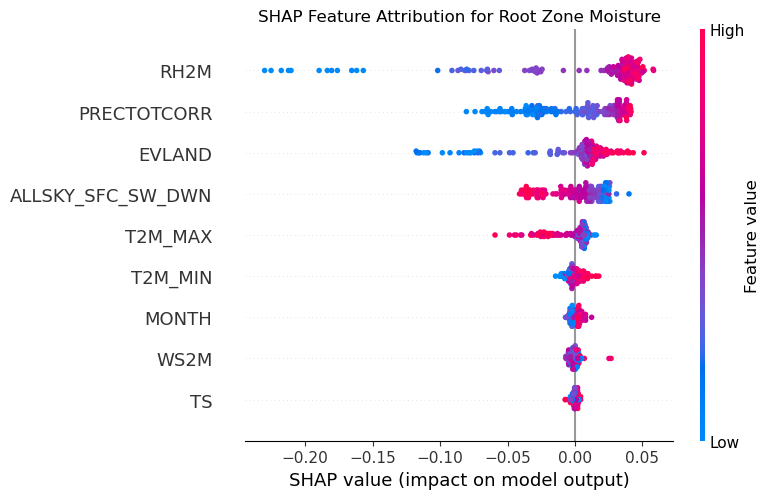

In [98]:
# 1. Initialize TreeExplainer (optimized for Random Forests)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# 2. Summary Beeswarm Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Feature Attribution for Root Zone Moisture", fontsize=12)
plt.tight_layout()
# plt.savefig("shap_summary.png", dpi=300)
plt.show()

## Interpretation

## Accumulated Local Effects (ALE)

PyALE._ALE_generic:INFO: Continuous feature detected.


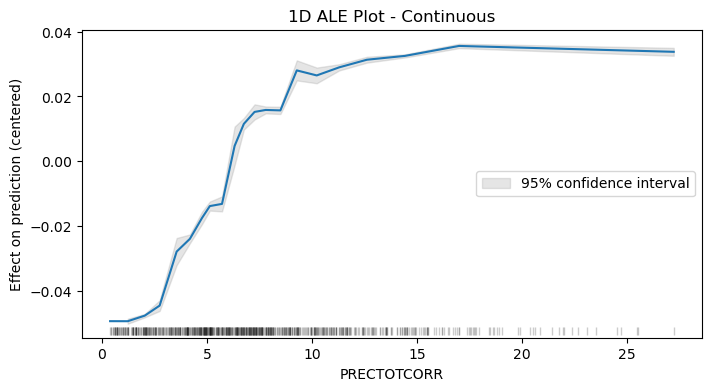

In [99]:
ale_eff = ale(
    X=X_train, 
    model=rf_model, 
    feature=["PRECTOTCORR"], 
    grid_size=20, 
    include_CI=True
)